# Predict admissions from projected age data

Predict the numbers of strokes from England population data in the future.

__Inputs:__

+ Numbers of people in five-year age bands for each MSOA for the years 2025, 2030, 2035, 2040.
+ Deprivation scores by MSOA.
+ Final probabilities of stroke given age and deprivation.

__Method:__

Multiply the probabilities of stroke by the numbers of people in each age band to predict the numbers of stroke by MSOA.

Find the standard deviation of each predicted number of strokes using the derived formula. This lets us set up a normal distribution for sampling numbers of strokes.

Link the MSOA to their nearest emergency stroke unit and so find the predicted number of admissions at these units for the coming years.

__Results:__

The numbers of strokes to units in Devon and Cornwall will increase. The rate of increase will increase until after 2030 when it falls.

## Code setup

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

### Projected population

The projected data file names contain these labels:

In [2]:
proj_years_str = ['2025', '2030', '2035', '2040']

Load in the data and store in a dictionary:

In [3]:
dict_df_proj_scaled = {}

for label in proj_years_str:
    df = pl.read_csv(os.path.join('data', 'projections', f'msoa_projections_{label}.csv'))
    dict_df_proj_scaled[label] = df

Check one of them:

In [4]:
dict_df_proj_scaled[proj_years_str[-1]]

MSOA,MSOA11CD,Age 0 - 4,Aged 5-9,Aged 10-14,Aged 15-19,Aged 20-24,Aged 25-29,Aged 30-34,Aged 35-39,Aged 40-44,Aged 45-49,Aged 50-54,Aged 55-59,Aged 60-64,Aged 65-69,Aged 70-74,Aged 75-79,Aged 80-84,Aged 85+,country
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str
"""Darlington 001""","""E02002559""",454,451,460,444,417,526,523,479,522,567,563,547,506,546,584,546,415,446,"""E"""
"""Darlington 002""","""E02002560""",308,306,312,301,283,357,355,325,354,384,382,371,343,370,396,370,281,303,"""E"""
"""Darlington 003""","""E02002561""",295,293,299,288,271,342,339,311,339,368,365,355,329,354,379,354,269,290,"""E"""
"""Darlington 004""","""E02002562""",311,309,316,304,286,361,359,328,358,389,386,376,347,375,401,374,284,306,"""E"""
"""Darlington 005""","""E02002563""",280,278,284,274,258,325,323,296,322,350,348,338,313,337,361,337,256,276,"""E"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""West Somerset 001""","""E02006113""",397,416,438,433,362,442,436,408,471,530,569,593,589,669,719,657,495,586,"""E"""
"""West Somerset 002""","""E02006114""",365,382,403,398,332,406,401,375,433,486,522,545,540,614,661,604,454,538,"""E"""
"""West Somerset 003""","""E02006115""",391,410,432,427,356,436,430,402,464,522,560,584,580,659,709,648,487,577,"""E"""


Gather data into age bands.

Set up a dictionary to say which age columns should be combined:

In [5]:
age_band_col_dict = {
    'age_less65': ['Age 0 - 4', 'Aged 5-9', 'Aged 10-14', 'Aged 15-19',
                   'Aged 20-24', 'Aged 25-29', 'Aged 30-34', 'Aged 35-39',
                   'Aged 40-44', 'Aged 45-49', 'Aged 50-54', 'Aged 55-59',
                   'Aged 60-64'],
    'age_65': ['Aged 65-69'],
    'age_70': ['Aged 70-74'],
    'age_75': ['Aged 75-79'],
    'age_over80': ['Aged 80-84', 'Aged 85+'],
}

Combine the columns:

In [6]:
for label, df in dict_df_proj_scaled.items():
    for key, col_list in age_band_col_dict.items():
        # Make a new column by summing anything required:
        df = df.with_columns(pl.Series(key, df[col_list].sum_horizontal()))
        # Remove original separate age columns:
        df = df.drop(col_list)
    dict_df_proj_scaled[label] = df

Check one of the resulting dataframes:

In [7]:
dict_df_proj_scaled[proj_years_str[-1]]

MSOA,MSOA11CD,country,age_less65,age_65,age_70,age_75,age_over80
str,str,str,i64,i64,i64,i64,i64
"""Darlington 001""","""E02002559""","""E""",6459,546,584,546,861
"""Darlington 002""","""E02002560""","""E""",4381,370,396,370,584
"""Darlington 003""","""E02002561""","""E""",4194,354,379,354,559
"""Darlington 004""","""E02002562""","""E""",4430,375,401,374,590
"""Darlington 005""","""E02002563""","""E""",3989,337,361,337,532
…,…,…,…,…,…,…,…
"""West Somerset 001""","""E02006113""","""E""",6084,669,719,657,1081
"""West Somerset 002""","""E02006114""","""E""",5588,614,661,604,992
"""West Somerset 003""","""E02006115""","""E""",5994,659,709,648,1064


Load MSOA demographic data for the IMD scores:

In [8]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

# Only keep columns for predictions:
df_stats = df_stats[['MSOA', 'MSOA11CD', 'depriv_quantile_min', 'depriv_quantile_max', 'age_less65', 'age_65', 'age_70', 'age_75', 'age_over80', 'admissions']]

In [9]:
df_stats.head()

MSOA,MSOA11CD,depriv_quantile_min,depriv_quantile_max,age_less65,age_65,age_70,age_75,age_over80,admissions
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""","""E02006534""",0.4,0.6,6939.168,492.7585,465.432,371.993,546.53,14.333333
"""Adur 002""","""E02006535""",0.8,1.0,5423.2821,419.8014,562.1562,357.3396,502.5996,7.333333
"""Adur 003""","""E02006536""",0.6,0.8,5683.9066,447.8586,428.0028,309.6034,486.0994,9.333333
"""Adur 004""","""E02006537""",0.2,0.4,8561.8962,492.063,463.4916,388.3594,675.1316,21.0
"""Adur 005""","""E02006538""",0.6,0.8,6923.7937,540.8223,606.953,385.0075,599.7058,13.666667


In [10]:
for label, df in dict_df_proj_scaled.items():
    # Only keep the deprivation columns:
    df = df.join(df_stats[['MSOA11CD', 'depriv_quantile_min', 'depriv_quantile_max']], on='MSOA11CD')
    dict_df_proj_scaled[label] = df

Store a copy with the predictions dataframes:

In [11]:
dict_df_proj_scaled['now'] = df_stats

Merge IMD scores into age projection data:

### Final coefficients:

In [12]:
df_best_nudged = pl.read_csv(os.path.join('outputs', 'nudge_walk_best.csv'))
df_best_coeffs = df_best_nudged.filter(df_best_nudged['fitness'] == df_best_nudged['fitness'].min())[0]
coeff_names = df_best_coeffs.columns[:25]
coeffs = df_best_coeffs[coeff_names].to_numpy().reshape(5, 5)

qmin_list = np.arange(0.0, 1.0, 0.2)

coeffs_depriv = pl.DataFrame()
coeffs_depriv = coeffs_depriv.with_columns(pl.Series('depriv_quantile_min', qmin_list))
for a, age_band in enumerate(['age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']):
    coeffs_depriv = coeffs_depriv.with_columns(pl.Series(age_band, coeffs[:, a]))                                                   

In [13]:
coeffs_depriv

depriv_quantile_min,age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64,f64
0.0,0.0006,0.005,0.005,0.007,0.012
0.2,0.0005,0.003,0.004,0.007,0.012
0.4,0.0003,0.002,0.004,0.006,0.012
0.6,0.0003,0.002,0.004,0.005,0.011
0.8,0.0003,0.002,0.002,0.005,0.011


In [14]:
cols_coeffs_depriv = [c for c in coeffs_depriv.columns if 'depriv' not in c]

## Predict admissions

Multiply the stroke coefficients by the numbers of people in each age band.

In [15]:
for label, df in dict_df_proj_scaled.items():
    # Separate calculation per deprivation quantile:
    df_admissions_here = df
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))

    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(np.round(df_admissions_here['depriv_quantile_min'], 1) == round(q, 1))
    
        coeffs_q = coeffs_depriv.filter(np.round(coeffs_depriv['depriv_quantile_min'], 1) == np.round(q, 1))[cols_coeffs_depriv]#.to_numpy()
        
        for a in cols_coeffs_depriv:
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (coeffs_q[a].to_numpy()[0] * df_here[a])))
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))
    df_admissions_here = df_admissions_here.drop(cols_pred)

    # Calculate uncertainty measure:
    std = 0.13 * df_admissions_here['admissions_predicted'] + 1.30
    df_admissions_here = df_admissions_here.with_columns(pl.Series('std', std))
    # df_admissions_here = df_admissions_here.with_columns(pl.Series('mean+std', df_admissions_here['admissions_predicted'] + std))
    # df_admissions_here = df_admissions_here.with_columns(pl.Series('mean-std', df_admissions_here['admissions_predicted'] - std))
    

    # Store result:
    dict_df_proj_scaled[label] = df_admissions_here

Check one of the resulting dataframes:

In [16]:
dict_df_proj_scaled[proj_years_str[-1]]

MSOA,MSOA11CD,country,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max,admissions_predicted,std
str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64
"""Adur 001""","""E02006534""","""E""",6726,643,649,591,893,0.4,0.6,20.1618,3.921034
"""Adur 002""","""E02006535""","""E""",5234,500,505,460,695,0.8,1.0,13.5252,3.058276
"""Adur 003""","""E02006536""","""E""",5600,535,541,492,744,0.6,0.8,15.558,3.32254
"""Adur 004""","""E02006537""","""E""",7990,764,771,702,1061,0.2,0.4,27.017,4.81221
"""Adur 005""","""E02006538""","""E""",6727,643,649,591,893,0.6,0.8,18.6781,3.728153
…,…,…,…,…,…,…,…,…,…,…,…
"""York 020""","""E02002791""","""E""",5461,360,377,352,577,0.8,1.0,11.2193,2.758509
"""York 021""","""E02002792""","""E""",5879,387,406,379,621,0.8,1.0,12.0757,2.869841
"""York 022""","""E02002793""","""E""",7656,504,529,494,808,0.6,0.8,16.7788,3.481244


In [17]:
dict_df_proj_scaled['now']

MSOA,MSOA11CD,depriv_quantile_min,depriv_quantile_max,age_less65,age_65,age_70,age_75,age_over80,admissions,admissions_predicted,std
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""","""E02006534""",0.4,0.6,6939.168,492.7585,465.432,371.993,546.53,14.333333,13.719313,3.083511
"""Adur 002""","""E02006535""",0.8,1.0,5423.2821,419.8014,562.1562,357.3396,502.5996,7.333333,10.906193,2.717805
"""Adur 003""","""E02006536""",0.6,0.8,5683.9066,447.8586,428.0028,309.6034,486.0994,9.333333,11.208011,2.757041
"""Adur 004""","""E02006537""",0.2,0.4,8561.8962,492.063,463.4916,388.3594,675.1316,21.0,18.431199,3.696056
"""Adur 005""","""E02006538""",0.6,0.8,6923.7937,540.8223,606.953,385.0075,599.7058,13.666667,14.108396,3.134091
…,…,…,…,…,…,…,…,…,…,…,…
"""York 020""","""E02002791""",0.8,1.0,4763.1724,388.178,484.7332,362.082,525.8344,14.333333,10.769363,2.700017
"""York 021""","""E02002792""",0.8,1.0,6177.4944,390.5048,349.8432,289.2344,464.9232,12.666667,9.894272,2.586255
"""York 022""","""E02002793""",0.6,0.8,7203.3018,560.8548,637.335,434.332,605.2322,16.333333,14.661254,3.205963


In [18]:
dict_df_proj_scaled[proj_years_str[-1]]['admissions_predicted'].is_nan().any()

False

In [19]:
dict_df_proj_scaled.keys()

dict_keys(['2025', '2030', '2035', '2040', 'now'])

In [24]:
for k in ['2025', '2035', 'now']:
    dict_df_proj_scaled[k].write_csv(os.path.join('outputs', f'msoa_stroke_predictions_{k}.csv'))

## Gather MSOA by nearest stroke unit

In [19]:
import stroke_maps.load_data

In [20]:
df_units = stroke_maps.load_data.stroke_unit_region_lookup()
df_units = pl.DataFrame(df_units.reset_index())

df_units.head(3)

postcode,stroke_team,short_code,ssnap_name,use_ivt,use_mt,use_msu,transfer_unit_postcode,lsoa,lsoa_code,region,region_code,region_type,country,icb,icb_code,isdn
str,str,str,str,i64,i64,i64,str,str,str,str,str,str,str,str,str,str
"""SY231ER""","""Bronglais Hospital (Aberystwyt…","""AB""","""Bronglais Hospital""",1,0,0,"""nearest""","""Ceredigion 002A""","""W01000512""","""Hywel Dda University Health Bo…","""W11000025""","""LHB""","""Wales""",null,null,null
"""CB20QQ""","""Addenbrooke's Hospital, Cambri…","""AD""","""Addenbrooke's Hospital""",1,1,1,"""nearest""","""Cambridge 013D""","""E01017995""","""NHS Cambridgeshire and Peterbo…","""E38000260""","""SICBL""","""England""","""NHS Cambridgeshire and Peterbo…","""E54000056""","""East of England (South)"""
"""L97AL""","""University Hospital Aintree, L…","""AI""","""University Hospital Aintree""",1,1,1,"""nearest""","""Liverpool 005A""","""E01006654""","""NHS Cheshire and Merseyside IC…","""E38000101""","""SICBL""","""England""","""NHS Cheshire and Merseyside In…","""E54000008""","""Cheshire and Merseyside"""


Limit to units that use IVT:

In [21]:
df_units = df_units.filter(df_units['use_ivt'] == 1)

Load LSOA travel times:

In [22]:
df_travel_lsoa = stroke_maps.load_data.travel_time_matrix_lsoa()

# Show the first five rows and columns:
df_travel_lsoa.iloc[:5, :5]

,B152TH,B714HJ,B95SS,BA13NG,BA214AT
LSOA,,,,,
Adur 001A,173.3,179.8,171.2,161.5,152.9
Adur 001B,173.3,179.8,172.3,161.5,152.9
Adur 001C,173.3,180.9,172.3,150.8,151.9
Adur 001D,173.3,180.9,172.3,161.5,152.9
Adur 001E,174.4,180.9,173.3,150.8,151.9


Limit to units that offer IVT:

In [23]:
df_travel_lsoa = df_travel_lsoa[df_units['postcode']]

Find nearest unit for each LSOA:

In [24]:
series_nearest_units = df_travel_lsoa.idxmin(axis='columns')

In [25]:
df_nearest_units = pl.DataFrame(
    np.vstack((series_nearest_units.index, series_nearest_units.values)).transpose(),
    schema=['LSOA', 'nearest_unit']
)

In [26]:
df_nearest_units

LSOA,nearest_unit
str,str
"""Adur 001A""","""BN25BE"""
"""Adur 001B""","""BN25BE"""
"""Adur 001C""","""BN112DH"""
"""Adur 001D""","""BN112DH"""
"""Adur 001E""","""BN112DH"""
…,…
"""York 024B""","""YO318HE"""
"""York 024C""","""YO318HE"""
"""York 024D""","""YO318HE"""


Link LSOA to MSOA:

In [27]:
lsoa_to_msoa = pl.read_csv(os.path.join('..', 'geography_data', 'data_tabular', 'LSOA_regions.csv'))

lsoa_to_msoa = lsoa_to_msoa[['LSOA11NM', 'MSOA11CD', 'MSOA11NM']]

Merge in nearest unit data:

In [28]:
lsoa_to_msoa = lsoa_to_msoa.join(df_nearest_units, left_on='LSOA11NM', right_on='LSOA')

In [29]:
lsoa_to_msoa

LSOA11NM,MSOA11CD,MSOA11NM,nearest_unit
str,str,str,str
"""Hartlepool 006B""","""E02002488""","""Hartlepool 006""","""TS198PE"""
"""Hartlepool 005B""","""E02002487""","""Hartlepool 005""","""TS198PE"""
"""Hartlepool 006A""","""E02002488""","""Hartlepool 006""","""TS198PE"""
"""Hartlepool 006C""","""E02002488""","""Hartlepool 006""","""TS198PE"""
"""Hartlepool 008A""","""E02002490""","""Hartlepool 008""","""TS198PE"""
…,…,…,…
"""Merthyr Tydfil 004B""","""W02000286""","""Merthyr Tydfil 004""","""CF479DT"""
"""Merthyr Tydfil 008D""","""W02000415""","""Merthyr Tydfil 008""","""CF479DT"""
"""Merthyr Tydfil 003A""","""W02000285""","""Merthyr Tydfil 003""","""CF479DT"""


Glob nearest unit by LSOA into nearest unit by MSOA by picking majority option:

In [30]:
msoa_nearest_units = lsoa_to_msoa.group_by("MSOA11NM", maintain_order=True).agg(pl.col("nearest_unit"))

msoa_nearest_units = msoa_nearest_units.rename({'nearest_unit': 'nearest_units_of_lsoa'})

In [31]:
msoa_nearest_units

MSOA11NM,nearest_units_of_lsoa
str,list[str]
"""Hartlepool 006""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]"
"""Hartlepool 005""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]"
"""Hartlepool 008""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]"
"""Hartlepool 001""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]"
"""Hartlepool 003""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]"
…,…
"""Merthyr Tydfil 003""","[""CF479DT"", ""CF479DT"", … ""CF479DT""]"
"""Merthyr Tydfil 002""","[""CF479DT"", ""CF479DT"", … ""CF479DT""]"
"""Merthyr Tydfil 005""","[""CF479DT"", ""CF479DT"", … ""CF479DT""]"


In [32]:
def find_mode(arr):
    values, counts = np.unique(arr, return_counts=True)
    mode_val = values[np.where(counts == max(counts))[0]]
    # Returns a list of one or more most-common values:
    return mode_val

In [33]:
selected_nearest_units = []

for units_list in msoa_nearest_units['nearest_units_of_lsoa']:
    most_common_nearest_units = find_mode(units_list)
    # Arbitrarily pick the first one alphabetically:
    unit = sorted(most_common_nearest_units)[0]
    selected_nearest_units.append(unit)

In [34]:
msoa_nearest_units = msoa_nearest_units.with_columns(pl.Series('nearest_unit', selected_nearest_units))

In [35]:
msoa_nearest_units

MSOA11NM,nearest_units_of_lsoa,nearest_unit
str,list[str],str
"""Hartlepool 006""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]","""TS198PE"""
"""Hartlepool 005""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]","""TS198PE"""
"""Hartlepool 008""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]","""TS198PE"""
"""Hartlepool 001""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]","""TS198PE"""
"""Hartlepool 003""","[""TS198PE"", ""TS198PE"", … ""TS198PE""]","""TS198PE"""
…,…,…
"""Merthyr Tydfil 003""","[""CF479DT"", ""CF479DT"", … ""CF479DT""]","""CF479DT"""
"""Merthyr Tydfil 002""","[""CF479DT"", ""CF479DT"", … ""CF479DT""]","""CF479DT"""
"""Merthyr Tydfil 005""","[""CF479DT"", ""CF479DT"", … ""CF479DT""]","""CF479DT"""


Pick out stroke units in the South West:

In [36]:
df_units['isdn'].unique().to_numpy()

array(['Wessex', 'West Midlands', 'Greater Manchester',
       'Gloucester, BSW, BNSSG and Somerset', 'East of England (North)',
       'London', 'North East and Cumbria', 'South Yorkshire',
       'West Yorkshire and Harrogate', 'Cheshire and Merseyside',
       'Frimley ICS', 'Lancashire and South Cumbria',
       'East of England (South)', 'North Midlands',
       'Humber Coast and Vale', 'East Midlands', None, 'Sussex',
       'Devon, Cornwall and Isles of Scilly', 'Kent and Medway',
       'Thames Valley'], dtype=object)

In [37]:
units_here = df_units.filter(df_units['isdn'].is_in(['Devon, Cornwall and Isles of Scilly']))#, 'Gloucester, BSW, BNSSG and Somerset']))

In [38]:
units_here

postcode,stroke_team,short_code,ssnap_name,use_ivt,use_mt,use_msu,transfer_unit_postcode,lsoa,lsoa_code,region,region_code,region_type,country,icb,icb_code,isdn
str,str,str,str,i64,i64,i64,str,str,str,str,str,str,str,str,str,str
"""EX314JB""","""North Devon District Hospital,…","""BP""","""North Devon District Hospital""",1,0,0,"""nearest""","""North Devon 007C""","""E01020134""","""NHS Devon ICB - 15N""","""E38000230""","""SICBL""","""England""","""NHS Devon Integrated Care Boar…","""E54000037""","""Devon, Cornwall and Isles of S…"
"""PL68DH""","""Derriford Hospital, Plymouth""","""DF""","""Derriford Hospital""",1,1,1,"""nearest""","""Plymouth 005C""","""E01015092""","""NHS Devon ICB - 15N""","""E38000230""","""SICBL""","""England""","""NHS Devon Integrated Care Boar…","""E54000037""","""Devon, Cornwall and Isles of S…"
"""EX25DW""","""Royal Devon and Exeter Hospita…","""EX""","""Royal Devon and Exeter Hospita…",1,0,0,"""nearest""","""Exeter 013C""","""E01020013""","""NHS Devon ICB - 15N""","""E38000230""","""SICBL""","""England""","""NHS Devon Integrated Care Boar…","""E54000037""","""Devon, Cornwall and Isles of S…"
"""TQ27AA""","""Torbay Hospital""","""TB""","""Torbay Hospital""",1,0,0,"""nearest""","""Torbay 003C""","""E01015251""","""NHS Devon ICB - 15N""","""E38000230""","""SICBL""","""England""","""NHS Devon Integrated Care Boar…","""E54000037""","""Devon, Cornwall and Isles of S…"
"""TR13LQ""","""Royal Cornwall Hospital, Truro""","""TR""","""Royal Cornwall Hospital""",1,0,0,"""nearest""","""Cornwall 043C""","""E01018855""","""NHS Cornwall and the Isles of …","""E38000089""","""SICBL""","""England""","""NHS Cornwall and the Isles of …","""E54000036""","""Devon, Cornwall and Isles of S…"


In [39]:
units_here_postcodes = units_here['postcode'].to_numpy()

mask = msoa_nearest_units['nearest_unit'].is_in(units_here_postcodes)

msoa_here = msoa_nearest_units.filter(mask)

In [40]:
msoa_here

MSOA11NM,nearest_units_of_lsoa,nearest_unit
str,list[str],str
"""Plymouth 009""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
"""Plymouth 011""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
"""Plymouth 007""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
"""Plymouth 004""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
"""Plymouth 021""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
…,…,…
"""West Devon 006""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
"""West Devon 005""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
"""West Devon 004""","[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""


Pick out admissions for these MSOA.

All MSOA first:

In [41]:
df_msoa_admissions = pl.DataFrame()

for label, df in dict_df_proj_scaled.items():
    df_msoa_admissions = df_msoa_admissions.with_columns(pl.Series(label, df['admissions_predicted']))
    df_msoa_admissions = df_msoa_admissions.with_columns(pl.Series(f'{label}_std', df['std']))
    # df_msoa_admissions = df_msoa_admissions.with_columns(pl.Series(f'{label}_plus_std', df['mean+std']))
    # df_msoa_admissions = df_msoa_admissions.with_columns(pl.Series(f'{label}_minus_std', df['mean-std']))
    if label == 'now':
        df_msoa_admissions = df_msoa_admissions.with_columns(pl.Series('HES', df['admissions']))
        for col in ['MSOA', 'MSOA11CD', 'depriv_quantile_min', 'depriv_quantile_max']:
            df_msoa_admissions = df_msoa_admissions.with_columns(df[col])

In [42]:
df_msoa_admissions

2025,2025_std,2030,2030_std,2035,2035_std,2040,2040_std,now,now_std,HES,MSOA,MSOA11CD,depriv_quantile_min,depriv_quantile_max
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64
16.3534,3.425942,17.813,3.61569,18.8968,3.756584,20.1618,3.921034,13.719313,3.083511,14.333333,"""Adur 001""","""E02006534""",0.4,0.6
11.0242,2.733146,12.059,2.86767,12.6876,2.949388,13.5252,3.058276,10.906193,2.717805,7.333333,"""Adur 002""","""E02006535""",0.8,1.0
12.6217,2.940821,13.7855,3.092115,14.621,3.20073,15.558,3.32254,11.208011,2.757041,9.333333,"""Adur 003""","""E02006536""",0.6,0.8
22.332,4.20316,24.0895,4.431635,25.429,4.60577,27.017,4.81221,18.431199,3.696056,21.0,"""Adur 004""","""E02006537""",0.2,0.4
15.1584,3.270592,16.5646,3.453398,17.5701,3.584113,18.6781,3.728153,14.108396,3.134091,13.666667,"""Adur 005""","""E02006538""",0.6,0.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9.1848,2.494024,10.0545,2.607085,10.6066,2.678858,11.2193,2.758509,10.769363,2.700017,14.333333,"""York 020""","""E02002791""",0.8,1.0
9.8785,2.584205,10.83,2.7079,11.4276,2.785588,12.0757,2.869841,9.894272,2.586255,12.666667,"""York 021""","""E02002792""",0.8,1.0
13.7162,3.083106,15.0405,3.255265,15.9429,3.372577,16.7788,3.481244,14.661254,3.205963,16.333333,"""York 022""","""E02002793""",0.6,0.8


In [43]:
(np.sign(np.diff(df_msoa_admissions[['2025', '2030', '2035', '2040']], axis=1)) >= 0).all()

True

In [44]:
df_msoa_admissions = df_msoa_admissions.join(msoa_nearest_units, left_on='MSOA', right_on='MSOA11NM')

In [45]:
units_here_postcodes = units_here['postcode'].to_numpy()

mask = df_msoa_admissions['nearest_unit'].is_in(units_here_postcodes)

df_msoa_admissions_here = df_msoa_admissions.filter(mask)

In [46]:
df_msoa_admissions_here

2025,2025_std,2030,2030_std,2035,2035_std,2040,2040_std,now,now_std,HES,MSOA,MSOA11CD,depriv_quantile_min,depriv_quantile_max,nearest_units_of_lsoa,nearest_unit
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,list[str],str
20.8754,4.013802,22.5026,4.225338,23.7332,4.385316,24.7748,4.520724,18.649563,3.724443,12.0,"""Plymouth 009""","""E02003130""",0.0,0.2,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
12.1398,2.878174,13.2769,3.025997,14.1724,3.142412,15.0815,3.260595,12.35619,2.906305,8.333333,"""Plymouth 011""","""E02003132""",0.4,0.6,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
17.663,3.59619,19.0278,3.773614,20.0816,3.910608,20.9788,4.027244,16.088672,3.391527,12.333333,"""Plymouth 007""","""E02003128""",0.0,0.2,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
12.2214,2.888782,13.1854,3.014102,13.9042,3.107546,14.5428,3.190564,12.294664,2.898306,7.666667,"""Plymouth 004""","""E02003125""",0.0,0.2,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
18.5308,3.709004,19.9888,3.898544,21.0964,4.042532,22.0142,4.161846,16.236155,3.4107,13.0,"""Plymouth 021""","""E02003142""",0.0,0.2,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
13.6041,3.068533,15.3712,3.298256,16.6869,3.469297,17.9716,3.636308,12.999408,2.989923,12.666667,"""West Devon 006""","""E02004234""",0.4,0.6,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
25.2857,4.587141,28.6355,5.022615,31.0892,5.341596,33.3482,5.635266,23.291214,4.327858,23.0,"""West Devon 005""","""E02004233""",0.6,0.8,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""
14.5094,3.186222,16.4024,3.432312,17.8149,3.615937,19.1782,3.793166,12.04734,2.866154,10.333333,"""West Devon 004""","""E02004232""",0.4,0.6,"[""PL68DH"", ""PL68DH"", … ""PL68DH""]","""PL68DH"""


Poisson sample some admissions from these predictions and stds:

In [47]:
cols_admissions = list(dict_df_proj_scaled.keys())

cols_admissions

['2025', '2030', '2035', '2040', 'now']

In [85]:
def normal_sample(mean, std, n_sampled=100):#, fudge=1.5):
    rng = np.random.default_rng()
    # Subtract stds so that sample dist is centred on zero.
    # samples = mean + (rng.poisson(std, n_sampled) - std)
    # Fudge factor:
    # samples = ((rng.poisson(mean, n_sampled) - mean) * fudge) + mean
    samples = np.random.normal(mean, std, n_sampled)

    return samples

In [86]:
dict_sampled = {}
for label in cols_admissions:
    n_bootstraps = 1000
    
    np.random.seed(42)
    
    df_sampled = pl.DataFrame()
    for i in range(len(df_msoa_admissions_here)):
        mean = df_msoa_admissions_here[i][label].to_numpy().flatten()[0]
        std = df_msoa_admissions_here[i][f'{label}_std'].to_numpy().flatten()[0]
            
        samples = normal_sample(mean, std, n_bootstraps)
    
        # Store results:
        df_here = pl.DataFrame(samples.reshape(1, len(samples)))
        df_sampled = pl.concat((df_sampled, df_here))

    # Copy over useful data from before:
    for col in [label, f'{label}_std', 'MSOA', 'MSOA11CD', 'depriv_quantile_min', 'depriv_quantile_max', 'nearest_unit']:
        df_sampled = df_sampled.with_columns(pl.Series(col, df_msoa_admissions_here[col]))        

    dict_sampled[label] = df_sampled

In [87]:
dict_sampled_admissions_by_unit = {}

for label in cols_admissions:
    df_sampled = dict_sampled[label]
    cols_sampled = [c for c in df_sampled.columns if c.startswith('column')]
    df_admissions_here = pl.DataFrame()
    
    for unit in units_here_postcodes:
        mask = df_sampled['nearest_unit'] == unit
        df_here = df_sampled.filter(mask)[cols_sampled].sum()
        df_here = df_here.with_columns(pl.Series('nearest_unit', [unit]))
        df_admissions_here = pl.concat((df_admissions_here, df_here))

    dict_sampled_admissions_by_unit[label] = df_admissions_here

In [88]:
df_hes_admissions_by_unit = pl.DataFrame()

for unit in units_here_postcodes:
    mask = df_msoa_admissions['nearest_unit'] == unit
    df_here = df_msoa_admissions.filter(mask)[['HES']].sum()
    df_here = df_here.with_columns(pl.Series('nearest_unit', [unit]))
    df_hes_admissions_by_unit = pl.concat((df_hes_admissions_by_unit, df_here))


In [89]:
df_hes_admissions_by_unit

HES,nearest_unit
f64,str
420.0,"""EX314JB"""
707.333333,"""PL68DH"""
593.0,"""EX25DW"""
564.0,"""TQ27AA"""
746.666667,"""TR13LQ"""


In [90]:
df_sampled_units = pl.DataFrame()

for unit in units_here_postcodes:
    df_cols = ['nearest_unit']
    df_vals = [unit]
    for label, df_sampled in dict_sampled_admissions_by_unit.items():
        cols_sampled = [c for c in df_sampled.columns if c.startswith('column')]
        vals = df_sampled.filter(df_sampled['nearest_unit'] == unit)[cols_sampled].to_numpy().flatten()
        mean = np.mean(vals)
        std = np.std(vals)

        df_cols += [f'{label}_mean', f'{label}_std']
        df_vals += [mean, std]
    df_here = pl.DataFrame(np.array(df_vals).reshape(1, len(df_vals)), schema=df_cols)
    df_sampled_units = pl.concat((df_sampled_units, df_here))

In [91]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [92]:
n_admissions_hes = df_stats['admissions'].sum()
n_admissions_ssnap = df_pop_admissions['admissions_annual'].sum()

admissions_scale = n_admissions_hes / n_admissions_ssnap

In [93]:
admissions_scale

1.4477813015864023

In [94]:
from polars.exceptions import InvalidOperationError

for col in df_sampled_units.columns:
    try:
        df_sampled_units = df_sampled_units.with_columns(pl.col(col).cast(float))
    except InvalidOperationError:
        pass

In [95]:
df_sampled_units_ssnap = df_sampled_units

for col in df_sampled_units_ssnap.columns:
    try:
        df_sampled_units_ssnap = df_sampled_units_ssnap.with_columns(pl.Series(col, df_sampled_units_ssnap[col] / admissions_scale))
        df_sampled_units_ssnap = df_sampled_units_ssnap.with_columns(pl.col(col).cast(int).round(0))
    except InvalidOperationError:
        pass

In [96]:
df_sampled_units

nearest_unit,2025_mean,2025_std,2030_mean,2030_std,2035_mean,2035_std,2040_mean,2040_std,now_mean,now_std
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""EX314JB""",415.639209,17.598716,466.73391,18.951369,506.877504,20.013863,546.601719,21.061229,370.297333,16.380328
"""PL68DH""",868.587093,25.948653,960.654506,27.617996,1029.175215,28.864625,1093.939388,30.03723,776.457285,24.149522
"""EX25DW""",678.057452,22.021746,765.426975,23.749824,834.944185,25.127126,903.055171,26.483404,600.418871,20.667883
"""TQ27AA""",589.227638,20.729633,663.778743,22.349627,721.397053,23.60476,775.608884,24.788906,521.285465,19.224407
"""TR13LQ""",942.411612,26.993337,1060.752339,29.140237,1150.945049,30.77772,1237.667838,32.349683,823.75104,24.920512


In [97]:
df_sampled_units_ssnap

nearest_unit,2025_mean,2025_std,2030_mean,2030_std,2035_mean,2035_std,2040_mean,2040_std,now_mean,now_std
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""EX314JB""",287,12,322,13,350,13,377,14,255,11
"""PL68DH""",599,17,663,19,710,19,755,20,536,16
"""EX25DW""",468,15,528,16,576,17,623,18,414,14
"""TQ27AA""",406,14,458,15,498,16,535,17,360,13
"""TR13LQ""",650,18,732,20,794,21,854,22,568,17


In [98]:
df_sampled_units_ssnap.sum()

nearest_unit,2025_mean,2025_std,2030_mean,2030_std,2035_mean,2035_std,2040_mean,2040_std,now_mean,now_std
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
null,2410,76,2703,83,2928,86,3144,91,2133,71


In [99]:
df_hes_admissions_by_unit

HES,nearest_unit
f64,str
420.0,"""EX314JB"""
707.333333,"""PL68DH"""
593.0,"""EX25DW"""
564.0,"""TQ27AA"""
746.666667,"""TR13LQ"""


In [100]:
(df_hes_admissions_by_unit['HES'] / admissions_scale).sum()

2093.548242880876

In [101]:
labels = ['now', '2025', '2030', '2035', '2040']

lines = []
header = ' '*4 + ' & SSNAP & ' + ' & '.join(labels) + ' \\\\'
lines.append(header)
lines.append('    \hline')

for unit in units_here_postcodes:
    unit_name = units_here.filter(units_here['postcode'] == unit)['ssnap_name'].to_numpy()[0]
    df = df_sampled_units_ssnap.filter(df_sampled_units_ssnap['nearest_unit'] == unit)
    row = ' '*4 + unit_name
    hes_here = df_hes_admissions_by_unit.filter(df_hes_admissions_by_unit['nearest_unit'] == unit)['HES'].to_numpy()[0] / admissions_scale
    row += f' & {hes_here:.1f}'
    for label in labels:
        mean = df[f'{label}_mean'].to_numpy()[0]
        std = df[f'{label}_std'].to_numpy()[0]
        row += f' & {mean} ({std})'
    row += ' \\\\'
    lines.append(row)


for l in lines:
    print(l)

     & SSNAP & now & 2025 & 2030 & 2035 & 2040 \\
    \hline
    North Devon District Hospital & 290.1 & 255 (11) & 287 (12) & 322 (13) & 350 (13) & 377 (14) \\
    Derriford Hospital & 488.6 & 536 (16) & 599 (17) & 663 (19) & 710 (19) & 755 (20) \\
    Royal Devon and Exeter Hospital & 409.6 & 414 (14) & 468 (15) & 528 (16) & 576 (17) & 623 (18) \\
    Torbay Hospital & 389.6 & 360 (13) & 406 (14) & 458 (15) & 498 (16) & 535 (17) \\
    Royal Cornwall Hospital & 515.7 & 568 (17) & 650 (18) & 732 (20) & 794 (21) & 854 (22) \\


In [102]:
np.diff(df_sampled_units[['now_mean', '2025_mean', '2030_mean', '2035_mean', '2040_mean']], axis=1)

array([[ 45.341876  ,  51.09470125,  40.14359421,  39.72421527],
       [ 92.12980838,  92.06741241,  68.52070903,  64.76417292],
       [ 77.63858119,  87.36952281,  69.51721047,  68.11098547],
       [ 67.94217279,  74.55110548,  57.61830948,  54.21183125],
       [118.66057278, 118.3407269 ,  90.19270997,  86.72278914]])

In [103]:
np.diff(df_sampled_units_ssnap[['now_mean', '2025_mean', '2030_mean', '2035_mean', '2040_mean']], axis=1)

array([[32, 35, 28, 27],
       [63, 64, 47, 45],
       [54, 60, 48, 47],
       [46, 52, 40, 37],
       [82, 82, 62, 60]])

Rate of increase highest for -> 2030 year, afterwards rate begins to slow.

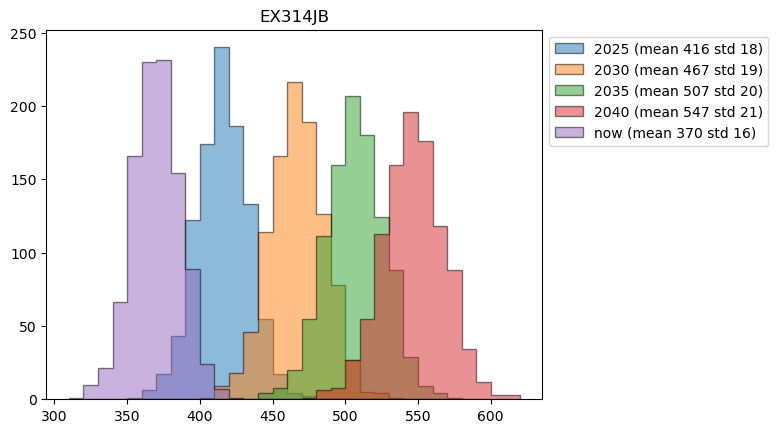

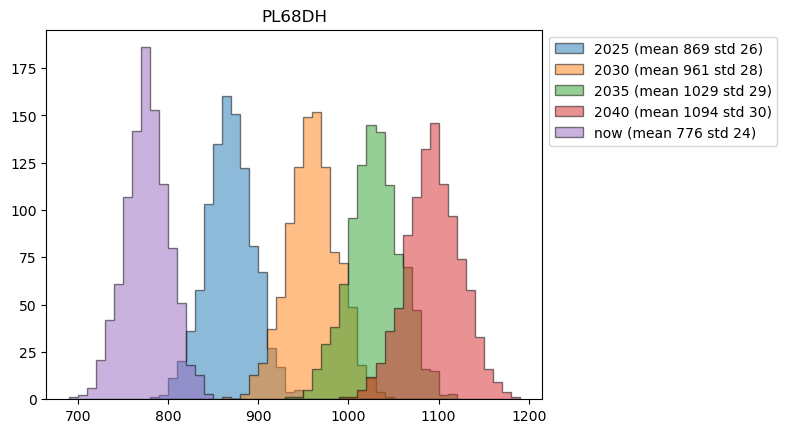

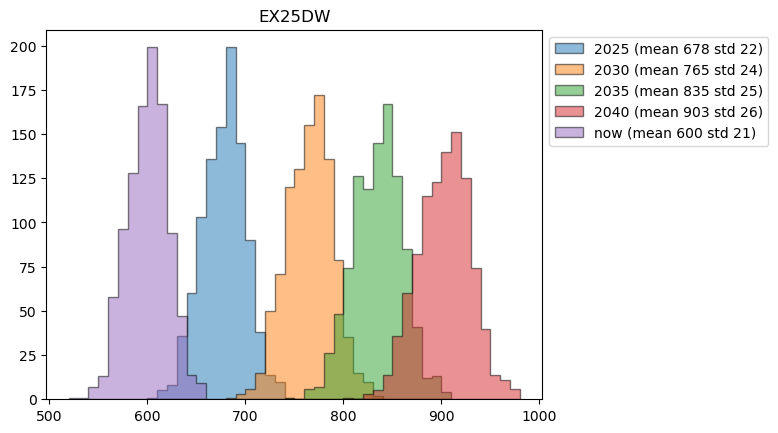

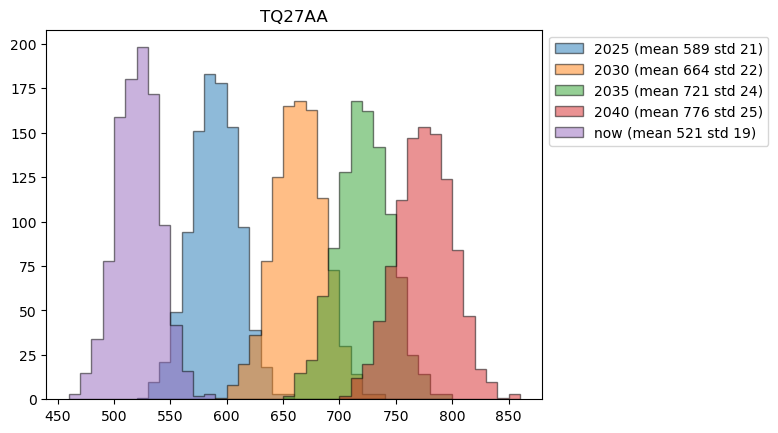

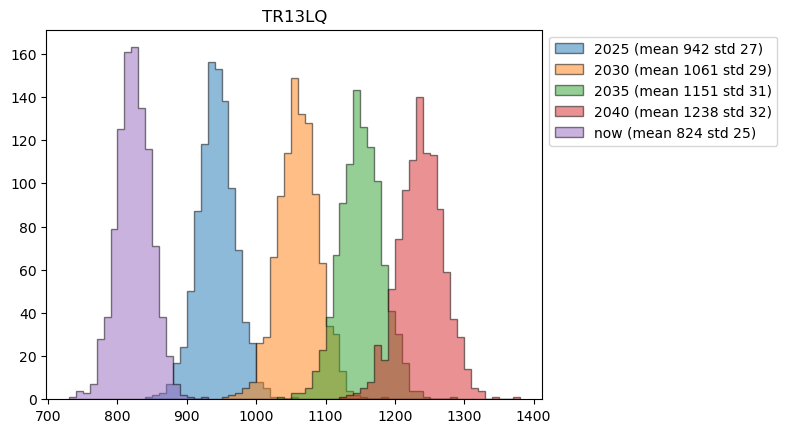

In [104]:
for unit in units_here_postcodes:
    fig, ax = plt.subplots()
    for label, df_sampled in dict_sampled_admissions_by_unit.items():
        cols_sampled = [c for c in df_sampled.columns if c.startswith('column')]
        vals = df_sampled.filter(df_sampled['nearest_unit'] == unit)[cols_sampled].to_numpy().flatten()
        mean = np.mean(vals)
        std = np.std(vals)

        bin_step = 10
        bin_min = bin_step * int(min(vals) / bin_step)
        bin_max = bin_step * np.ceil(max(vals) / bin_step)
        bins = np.arange(bin_min, bin_max+bin_step, bin_step)
        
        ax.hist(vals, bins=bins, histtype='stepfilled',
                label=f'{label} (mean {mean:.0f} std {std:.0f})',
                alpha=0.5, edgecolor='k')
        ax.set_title(f'{unit}')# ({label})')
        # ax.annotate(f'mean {mean:.0f} std {std:.0f}', xy=(0.05, 0.95), xycoords='axes fraction')
    ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
    plt.show()
        